# Offensive IT-Tester — Exploratory Data Analysis

Dataset: cleaned web-application payloads (`payloads_clean.csv`, 455 rows).
Each step below answers a concrete question that feeds either the **classifier**
design or a **responsible-AI** deliverable (fairness, explainability, risk).

Run this from the project root *or* from `notebooks/` — the path resolves either way.

In [9]:

import re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (8, 4)

# resolve the cleaned file whether we're in project root or notebooks/
candidates = [
    Path.cwd() / "data" / "cleaned" / "payloads_clean.csv",
    Path.cwd().parent / "data" / "cleaned" / "payloads_clean.csv",
]
CSV = next((p for p in candidates if p.exists()), candidates[0])
df = pd.read_csv(CSV)
# restore ordered severity (categoricals don't survive CSV round-trip)
df["severity"] = pd.Categorical(df["severity"],
                                categories=["low", "medium", "high", "critical"],
                                ordered=True)
print("loaded", CSV)
df.shape

loaded c:\Users\yuvra\Desktop\UNI\RADE\data\cleaned\payloads_clean.csv


(455, 8)

## 1. Sanity check

Shape, types, and missing values. Watch `example` — it is null for many rows
(the merged `example_query`/`example_usage` field), so it is not a reliable feature.

In [10]:
display(df.head())
print("dtypes:"); print(df.dtypes)
print("\nmissing / empty per column:")
print(df.isna().sum())

,id,attack_class,payload,type,severity,context,description,example
0,sqli-001,sqli,' OR '1'='1,tautology,high,Login form username input,Basic tautology-based SQL injection,SELECT * FROM users WHERE username = '' OR '1'='1' AND password = ''
1,sqli-002,sqli,"' UNION SELECT username, password FROM users--",union,high,Search input field,Union-based SQL injection to extract data,"SELECT name, description FROM products WHERE name = '' UNION SELECT username..."
2,sqli-003,sqli,'; WAITFOR DELAY '0:0:5'--,blind-time,medium,ID parameter in URL,Blind SQL injection with time delay,SELECT * FROM orders WHERE id = ''; WAITFOR DELAY '0:0:5'--
3,sqli-004,sqli,"' AND 1=CONVERT(int,@@version)--",error-based,medium,User ID input,Error-based SQL injection to reveal database version,"SELECT * FROM users WHERE id = '' AND 1=CONVERT(int,@@version)--"
4,sqli-005,sqli,' AND 1=1--,boolean-blind,medium,Search field,Boolean-based blind SQL injection,SELECT * FROM products WHERE name = '' AND 1=1--


dtypes:
id                   str
attack_class         str
payload              str
type                 str
severity        category
context              str
description          str
example              str
dtype: object

missing / empty per column:
id                0
attack_class      0
payload           0
type              0
severity          0
context           0
description       0
example         248
dtype: int64


## 2. Class distribution (the target)

Confirms the mild imbalance after dedup. Implication: use a **stratified**
train/test split and consider `class_weight='balanced'`.

attack_class
xss     100
csrf     95
cmdi     88
sqli     87
ssrf     85
Name: count, dtype: int64


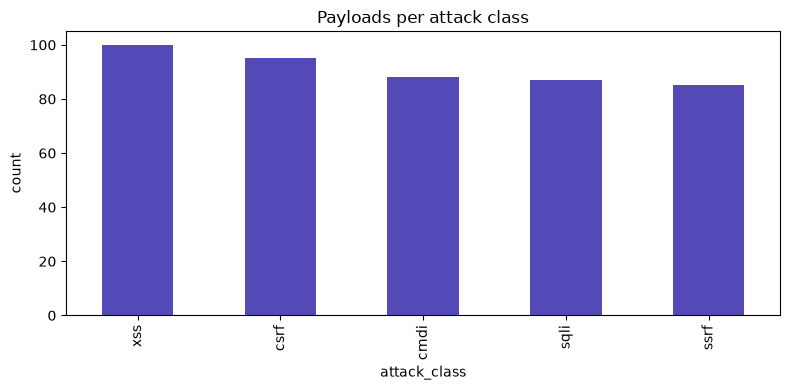

In [11]:
vc = df["attack_class"].value_counts()
print(vc)
ax = vc.plot(kind="bar", color="#534AB7")
ax.set_title("Payloads per attack class"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

## 3. Severity distribution (overall and per class)

Feeds risk scoring and the fairness evaluation. A class skewed toward
`critical` is a fairness dimension worth reporting.

severity
low          12
medium      138
high        242
critical     63
Name: count, dtype: int64


severity,low,medium,high,critical
attack_class,,,,
cmdi,0,29,40,19
csrf,4,24,55,12
sqli,0,58,18,11
ssrf,8,27,29,21
xss,0,0,100,0


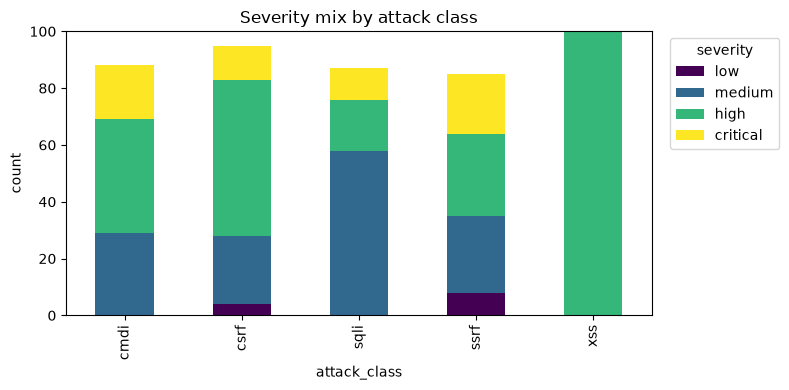

In [12]:
print(df["severity"].value_counts().sort_index())
ct = pd.crosstab(df["attack_class"], df["severity"])
display(ct)
ct.plot(kind="bar", stacked=True, colormap="viridis")
plt.title("Severity mix by attack class"); plt.ylabel("count")
plt.legend(title="severity", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

## 4. Sub-type richness per class

How many distinct `type` values sit inside each attack class. This is the
metadata the agent's `select_payloads` tool exploits for selectivity.

In [13]:
subtypes = df.groupby("attack_class")["type"].nunique().sort_values(ascending=False)
print("distinct sub-types per class:"); print(subtypes)
print("\nexample sub-types for xss:")
print(df.loc[df.attack_class == "xss", "type"].value_counts().head())

distinct sub-types per class:
attack_class
sqli    6
xss     2
cmdi    1
csrf    1
ssrf    1
Name: type, dtype: int64

example sub-types for xss:
type
reflected    54
stored       46
Name: count, dtype: int64


## 5. Context vs class

Which contexts map to which classes. `select_payloads` filters on `context`,
so this shows the coverage the agent has to work with.

In [14]:
top_ctx = df["context"].value_counts().head(12)
print("top contexts:"); print(top_ctx)
ctx_ct = pd.crosstab(df["context"], df["attack_class"])
ctx_ct = ctx_ct.loc[top_ctx.index]           # focus on the common contexts
display(ctx_ct)

top contexts:
context
URL parameter             55
Malicious webpage         46
User input field          43
Search input              25
User input                20
ID parameter              11
User ID input              7
Login username             7
Login form                 5
Search field               3
Execute whoami command     3
Login input                2
Name: count, dtype: int64


attack_class,cmdi,csrf,sqli,ssrf,xss
context,,,,,
URL parameter,0,0,1,0,54
Malicious webpage,0,46,0,0,0
User input field,0,0,0,0,43
Search input,0,0,25,0,0
User input,0,0,20,0,0
ID parameter,0,0,11,0,0
User ID input,0,0,7,0,0
Login username,0,0,7,0,0
Login form,0,0,5,0,0


## 6. Payload length by class  (the modelling risk)

If length alone separates classes, a model can learn a **shortcut** instead of
real structure. Inspect this before choosing features.

                    mean   min    max
attack_class                         
cmdi           41.704545   2.0  701.0
csrf          203.789474  60.0  804.0
sqli           35.252874   9.0   92.0
ssrf           29.941176  13.0   79.0
xss            52.870000  26.0  109.0


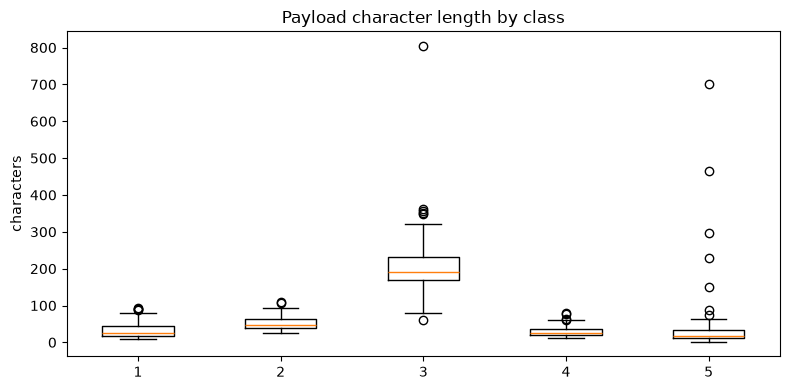

In [15]:
df["payload_len"] = df["payload"].str.len()
df["token_count"] = df["payload"].str.split().apply(len)
print(df.groupby("attack_class")["payload_len"].describe()[["mean", "min", "max"]])
data = [df.loc[df.attack_class == k, "payload_len"] for k in df.attack_class.unique()]
plt.boxplot(data, label=df.attack_class.unique())
plt.title("Payload character length by class"); plt.ylabel("characters")
plt.tight_layout(); plt.show()

## 7. Distinctive tokens per class

Lightweight lexical fingerprint. These are the tokens that make each class
recognisable — the groundwork for both feature engineering and explainability.

In [16]:
def tokenize(s):
    return re.findall(r"[A-Za-z_]+|[<>/;|&`$(){}=]", str(s).lower())

overall = Counter()
per_class = {}
for k, grp in df.groupby("attack_class"):
    cnt = Counter()
    for p in grp["payload"]:
        cnt.update(set(tokenize(p)))     # presence per payload, not raw freq
    per_class[k] = cnt
    overall.update(cnt)

for k, cnt in per_class.items():
    n = len(df[df.attack_class == k])
    # distinctiveness: share within class minus share overall
    scored = sorted(cnt.items(),
                    key=lambda kv: kv[1]/n - overall[kv[0]]/len(df),
                    reverse=True)
    print(f"{k:6s}:", [t for t, _ in scored[:8]])

cmdi  : ['echo', ';', '&', '$', 'whoami', 'injected', '|', 'attacker']
csrf  : ['https', 'com', 'post', 'method', 'script', '<', 'action', '>']
sqli  : ['or', 'select', 'sleep', 'from', 'users', 'and', 'where', 'substring']
ssrf  : ['http', '/', 'passwd', 'etc', 'smb', 'metadata', 'ftp', 'share']
xss   : ['alert', 'xss', '<', '>', ')', '(', '=', 'svg']


## 8. Leakage audit

The class label is derived from the `id` prefix, so `id` **must not** be a
feature. `description` and `example` also often name the attack outright —
treat them as documentation, not model input.

In [17]:
leaky = []
for col in ["id", "description", "example"]:
    hits = df.apply(lambda r: str(r["attack_class"]) in str(r[col]).lower(), axis=1).sum()
    leaky.append((col, int(hits)))
print("rows where the column literally contains the class name:")
for col, n in leaky:
    print(f"  {col:12s} {n}/{len(df)}")
print("\nSAFE feature columns: payload  (+ engineered: payload_len, token_count)")
print("UNSAFE (leak label): id, description, example, type is borderline")

rows where the column literally contains the class name:
  id           455/455
  description  281/455
  example      96/455

SAFE feature columns: payload  (+ engineered: payload_len, token_count)
UNSAFE (leak label): id, description, example, type is borderline


## 9. Key findings

- **455 clean rows, 5 balanced classes** — small but usable; expect the *small
  data* constraint to dominate model choice (favour simple, regularised models).
- **No benign class** — the dataset is all-attack, so a classifier trained on it
  alone cannot say "this is safe". Flag this as the central scope gap.
- **Rich metadata** (`type`, `context`, `severity`) supports agent selectivity
  and the risk/fairness deliverables.
- **Leakage risk** is real: only `payload` (and features derived from it) is a
  safe input. Document this in the model card.